# Lab 05 — Error Analysis on California Housing

**Goal:** practise looking *into* a model's mistakes, not just at its aggregate metric. Build a regression model, find the rows where it fails worst, and look for a pattern.

Pair with `docs/07_model_evaluation.md`.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42

## 2. Load + split + train a Ridge model

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
model = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=kf).fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print(f'RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'MAE  = {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R^2  = {r2_score(y_test, y_pred):.4f}')
print(f'alpha selected = {model.alpha_:.3g}')

RMSE = 0.7455
MAE  = 0.5332
R^2  = 0.5759
alpha selected = 2.98


## 3. Residuals — global view

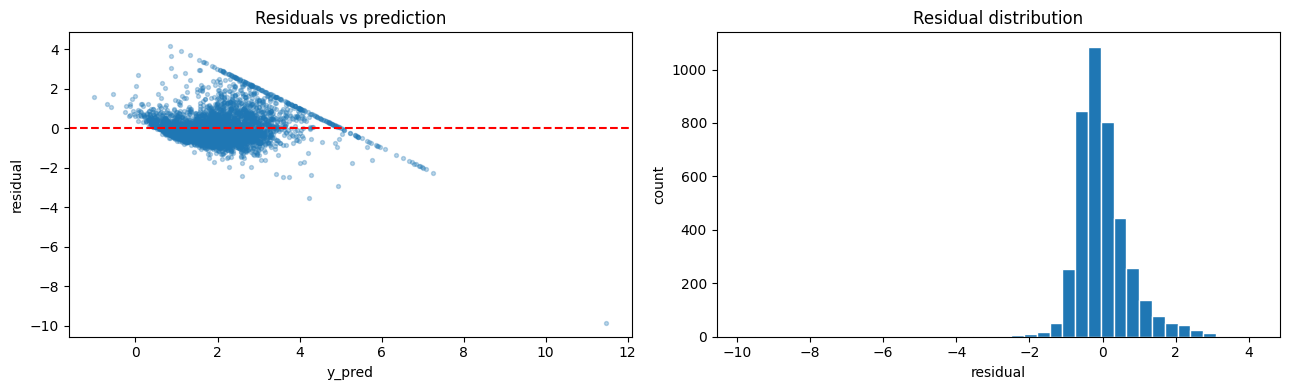

In [3]:
residuals = y_test.values - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3, s=8)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('y_pred'); axes[0].set_ylabel('residual')
axes[0].set_title('Residuals vs prediction')
axes[1].hist(residuals, bins=40, edgecolor='white')
axes[1].set_xlabel('residual'); axes[1].set_ylabel('count')
axes[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()

Residuals look roughly symmetric around 0 but heavy-tailed at both ends — the model is OK on the average house but blows up at the tails. The 5.0 cap on `MedHouseVal` is partly responsible (Chapter 6 mentioned this).

## 4. Where are the worst residuals?

In [4]:
test_idx = X_test.index                       # original DataFrame index
diag = X_test.copy()
diag['y_true']   = y_test.values
diag['y_pred']   = y_pred
diag['abs_err']  = np.abs(residuals)
diag.sort_values('abs_err', ascending=False).head(10).round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,y_true,y_pred,abs_err
1979,4.625,34.0,132.533,34.067,36.0,2.400,38.80,-120.08,1.625,11.478,9.853
6688,0.500,28.0,7.677,1.871,142.0,4.581,34.15,-118.08,5.000,0.851,4.149
10574,1.966,6.0,4.795,1.159,125.0,2.841,33.72,-117.70,5.000,1.115,3.885
12389,3.773,24.0,10.954,1.848,473.0,1.996,33.75,-116.43,5.000,1.321,3.679
19542,1.768,39.0,5.000,0.889,22.0,2.444,37.63,-120.92,4.500,0.868,3.632
4548,7.575,52.0,3.143,1.000,55.0,7.857,34.02,-118.21,0.675,4.236,3.561
459,1.170,52.0,2.436,0.944,1349.0,5.396,37.87,-122.25,5.000,1.547,3.453
15652,0.900,52.0,2.237,1.054,3260.0,2.237,37.80,-122.41,5.000,1.642,3.358
12069,4.239,6.0,7.723,1.169,228.0,3.508,33.83,-117.55,5.000,1.668,3.332
4630,2.367,20.0,2.741,1.048,2919.0,2.451,34.07,-118.31,5.000,1.710,3.290


Several patterns to watch for:
- High-spend areas (`MedInc` > 8) often underpredicted.
- Coastal blocks (low Longitude, mid Latitude) underpredicted.
- Blocks with `AveOccup` > 5 are sometimes wildly off — small / unusual blocks.

## 5. Slice by `MedInc` bin

In [5]:
diag['med_inc_bin'] = pd.cut(diag['MedInc'], bins=[0, 2, 4, 6, 8, 15])
by_bin = diag.groupby('med_inc_bin', observed=True).agg(
    n=('abs_err', 'size'),
    mean_abs_err=('abs_err', 'mean'),
    median_y=('y_true', 'median'),
).round(3)
by_bin

,n,mean_abs_err,median_y
med_inc_bin,,,
"(0, 2]",499,0.449,0.904
"(2, 4]",2066,0.492,1.550
"(4, 6]",1111,0.610,2.271
"(6, 8]",317,0.601,3.278
"(8, 15]",127,0.599,5.000


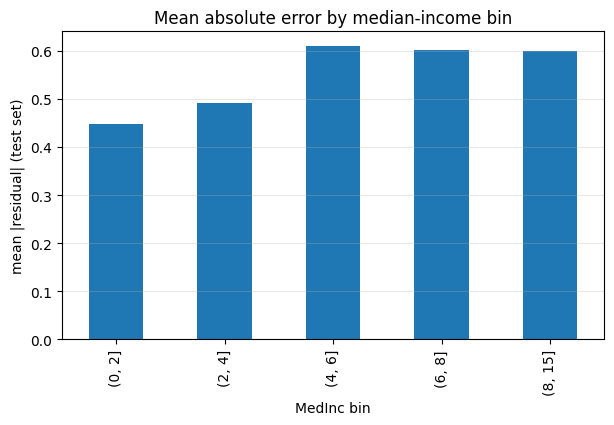

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
by_bin['mean_abs_err'].plot(kind='bar', ax=ax)
ax.set_ylabel('mean |residual| (test set)')
ax.set_title('Mean absolute error by median-income bin')
ax.set_xlabel('MedInc bin'); ax.grid(True, alpha=0.3, axis='y')
plt.show()

Average error grows monotonically with median income. The richest blocks are the hardest to predict — both because the target is *capped* at 5.0 and because there are fewer training samples up there.

## 6. Slice by geography

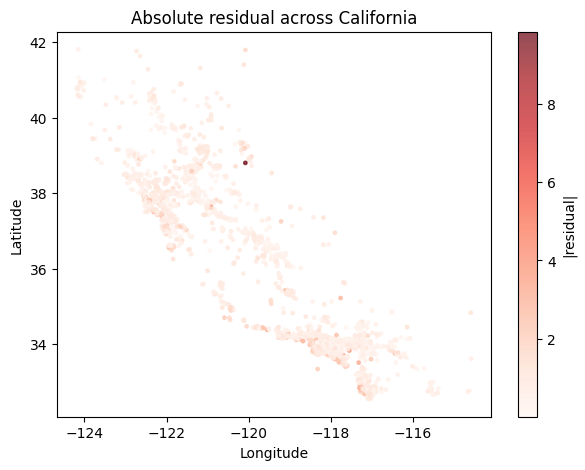

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(diag['Longitude'], diag['Latitude'], c=diag['abs_err'], cmap='Reds', s=6, alpha=0.7)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Absolute residual across California')
plt.colorbar(sc, ax=ax, label='|residual|')
plt.show()

Bright dots cluster on the coast (LA / Bay Area), where the linear model can't capture the geographic premium without explicit lat/lon-interaction features.

## 7. Write the error-analysis summary

Three paragraphs you would put into a report.

**1. Aggregate performance.** RMSE ≈ 0.73 on the test set; $R^2 \approx 0.58$. Acceptable for a baseline linear model but well below what tree-based ensembles achieve (~0.83 with the same features).

**2. Failure modes.** Error grows with median income — the model underpredicts expensive areas. Geographically, residuals concentrate on the coast (LA, Bay Area, San Diego). Both reflect missing non-linear / interaction features (e.g. distance-to-coast, log income).

**3. Next steps.** (a) Replace `MedHouseVal` with the uncapped raw target (if available). (b) Add coast-distance and city-cluster features. (c) Try gradient-boosted trees on the same features as a stronger baseline. Hyperparameter tuning of the linear model itself is unlikely to close the gap further.

## 8. Summary

- Aggregate metrics give you a headline; *slicing* by a meaningful feature gives you a plan.
- Always sort by absolute residual and look at the top examples.
- Two slices (MedInc and geography) revealed the structural failure modes within minutes.
- The output of error analysis is **a specific list of next experiments**, not just "the model needs work".